In [ ]:
from google.colab import drive
import os

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Define the path to YOUR specific project folder in Drive
# Replace 'Your_Project_Folder_Name' with the actual name of the folder you uploaded
project_path = '/content/drive/MyDrive/sentiment-analysis-project'

# 3. Change the current working directory to that folder
os.chdir(project_path)

# 4. Verify where you are
print("Current Working Directory:", os.getcwd())
!ls  # This will list the files in your project folder to confirm

Mounted at /content/drive
Current Working Directory: /content/drive/MyDrive/sentiment-analysis-project
anaconda_projects  apps  data  models  notebooks  results  src


In [ ]:
pip install tensorflow keras

1️⃣ Import libraries

In [ ]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

2️⃣ Load cleaned dataset

In [ ]:
import pandas as pd
import os

# The path to the cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/sentiment-analysis-project/data/proceeded/cleaned_reviews.csv")

print("DataFrame shape:", df.shape)
print("DataFrame head:")
print(df.head())

DataFrame shape: (23486, 2)
DataFrame head:
                                          final_text sentiment
0        absolutely wonderful silky sexy comfortable  positive
1  love dress sooo pretty happened find store gla...  positive
2  high hope dress really wanted work initially o...   neutral
3  love love love jumpsuit fun flirty fabulous ev...  positive
4  shirt flattering due adjustable front tie perf...  positive


In [ ]:
df["final_text"] = df["final_text"].fillna("")

3️⃣ Select features and labels

In [ ]:
from sklearn.model_selection import train_test_split

X = df["final_text"]
y = df["sentiment"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 18788
Test size: 4698


5️⃣ Tokenization (Text → numbers)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
max_words = 10000
max_len = 200

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

#Convert text to sequences:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


print("Example review:")
print(X_train.iloc[0])

print("\nTokenized sequence:")
print(X_train_seq[0])

Example review:
dress fit well comfortable reflection hit mid shin rather appears model

Tokenized sequence:
[2, 3, 22, 28, 4279, 163, 448, 3200, 379, 503, 86]


7️⃣ Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

#8️⃣ Encode Sentiment Labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Classes:", le.classes_)

Training shape: (18788, 200)
Testing shape: (4698, 200)
Classes: ['negative' 'neutral' 'positive']


9️⃣ Final Check   

In [ ]:
print("X_train_pad:", X_train_pad.shape)
print("X_test_pad:", X_test_pad.shape)

print("y_train_encoded:", y_train_encoded.shape)
print("y_test_encoded:", y_test_encoded.shape)

X_train_pad: (18788, 200)
X_test_pad: (4698, 200)
y_train_encoded: (18788,)
y_test_encoded: (4698,)




 # **Stage 3.2 — LSTM Model**

In [ ]:
#1️⃣ Import Deep Learning Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [ ]:
#2️⃣ Define Model Architecture
model = Sequential([

    Embedding(
        input_dim=10000,   # vocabulary size
        output_dim=128,    # word embedding size
        input_length=200   # sequence length
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(3, activation="softmax")  # positive, neutral, negative
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
#3️⃣ Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(3.2533333333333334), 1: np.float64(2.726454796110869), 2: np.float64(0.4299510275069797)}


In [ ]:
#4️⃣ Train Model
history = model.fit(

    X_train_pad,
    y_train_encoded,

    epochs=15,
    batch_size=128,

    validation_split=0.2,
    verbose=1
)

Epoch 1/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 139s 970ms/step - accuracy: 0.7693 - loss: 0.7330 - val_accuracy: 0.7829 - val_loss: 0.6731
Epoch 2/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 115s 837ms/step - accuracy: 0.7734 - loss: 0.7110 - val_accuracy: 0.7829 - val_loss: 0.6727
Epoch 3/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 101s 855ms/step - accuracy: 0.7734 - loss: 0.7057 - val_accuracy: 0.7829 - val_loss: 0.6727
Epoch 4/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 100s 851ms/step - accuracy: 0.7734 - loss: 0.7038 - val_accuracy: 0.7829 - val_loss: 0.6726
Epoch 5/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 97s 819ms/step - accuracy: 0.7734 - loss: 0.7048 - val_accuracy: 0.7829 - val_loss: 0.6726
Epoch 6/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 99s 838ms/step - accuracy: 0.7734 - loss: 0.7020 - val_accuracy: 0.7829 - val_loss: 0.6737
Epoch 7/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 99s 841ms/step - accuracy: 0.7734 - loss: 0.7025 - val_accuracy: 0.7829 - val_loss: 0.6729
Epoch 8/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 98s 832ms/step - accuracy: 0.7734 - los

In [ ]:
#5️⃣ Evaluate Model
loss, accuracy = model.evaluate(X_test_pad, y_test_encoded)

print("Test Accuracy:", accuracy)

#6️⃣ Predictions
y_pred = model.predict(X_test_pad)

y_pred_classes = y_pred.argmax(axis=1)

#Convert predictions back to labels:

y_pred_labels = le.inverse_transform(y_pred_classes)

#7️⃣ Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_labels))

147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.7752 - loss: 0.6881
Test Accuracy: 0.7752234935760498
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       482
     neutral       0.00      0.00      0.00       574
    positive       0.78      1.00      0.87      3642

    accuracy                           0.78      4698
   macro avg       0.26      0.33      0.29      4698
weighted avg       0.60      0.78      0.68      4698



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


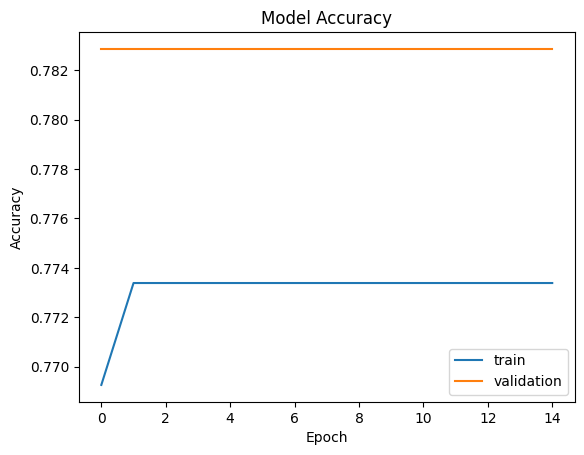

In [ ]:
#8️⃣ Plot Training History
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()




 # **Stage 3.3 — BERT & transformers**

In [ ]:
#install transformers and torch for BERT

#2️⃣ Import
from transformers import pipeline
import pandas as pd
import torch
from sklearn.metrics import classification_report, accuracy_score

#3️⃣ Load BERT pipeline (USE GPU 0)
# Changed device from 1 to 0 because Colab typically only provides one GPU
device = 0 if torch.cuda.is_available() else -1

bert_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
X_test_sample = X_test.iloc[:1000].tolist()
y_test_sample = y_test.iloc[:1000]

bert_results = bert_classifier(X_test_sample)

In [ ]:
def convert_bert_output(result):
    if result["label"] == "POSITIVE":
        return "positive"
    else:
        return "negative"

bert_predictions = [convert_bert_output(r) for r in bert_results]

In [ ]:
mask = y_test_sample.isin(["positive", "negative"])

y_true = y_test_sample[mask]
y_pred = [p for p, m in zip(bert_predictions, mask) if m]

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

Accuracy: 0.7049941927990708
              precision    recall  f1-score   support

    negative       0.25      0.82      0.39        97
    positive       0.97      0.69      0.81       764

    accuracy                           0.70       861
   macro avg       0.61      0.76      0.60       861
weighted avg       0.89      0.70      0.76       861



In [ ]:
# 8. Take subset (important)
X_test_sample = X_test.iloc[:1000].tolist()
y_test_sample = y_test.iloc[:1000]

# 9. Run predictions
print("Running BERT inference...")
bert_results = bert_classifier(X_test_sample)

# 10. Convert labels
def convert_bert_output(result):
    return "positive" if result["label"] == "POSITIVE" else "negative"

bert_predictions = [convert_bert_output(r) for r in bert_results]

# 11. Remove neutral class
mask = y_test_sample.isin(["positive", "negative"])

y_true = y_test_sample[mask]
y_pred = [p for p, m in zip(bert_predictions, mask) if m]

# 12. Evaluation
print("\n===== BERT RESULTS =====")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Running BERT inference...

===== BERT RESULTS =====
Accuracy: 0.7049941927990708

Classification Report:

              precision    recall  f1-score   support

    negative       0.25      0.82      0.39        97
    positive       0.97      0.69      0.81       764

    accuracy                           0.70       861
   macro avg       0.61      0.76      0.60       861
weighted avg       0.89      0.70      0.76       861



# **Stage 3.4 — Aspect-Based Sentiment**


In [ ]:
# ==============================
# STAGE 3.4 - ASPECT SENTIMENT
# ==============================

# Define aspects
aspects = {
    "quality": [
        "quality", "material", "fabric", "durability", "cheaply", "well made"
    ],
    "price": [
        "price", "expensive", "cheap", "cost", "value", "worth"
    ],
    "fit": [
        "fit", "size", "tight", "loose", "small", "large",
        "slim", "slimmer", "oversized", "perfectly"
    ],
    "delivery": [
        "delivery", "shipping", "arrived", "package", "late", "fast"
    ]
}

# Function to extract aspect sentiment
def extract_aspect_sentiment(text):

    results = {}
    text_lower = text.lower()

    for aspect, keywords in aspects.items():

        if any(word in text_lower for word in keywords):

            # Use full text (since punctuation removed)
            aspect_text = text

            seq = tokenizer.texts_to_sequences([aspect_text])
            pad = pad_sequences(seq, maxlen=200)

            pred = model.predict(pad, verbose=0)
            label = le.inverse_transform([pred.argmax()])[0]

            results[aspect] = label

    return results

# ==============================
# TEST ON SAMPLE
# ==============================

sample_review = X_test.iloc[0]

print("Review:\n", sample_review)

aspect_result = extract_aspect_sentiment(sample_review)

print("\nAspect Sentiment:\n", aspect_result)

Review:
 tried dress store absolutely fell love bigger gal busty wider hip dress made look feel slimmer light wear dress perfect length dress hit right ankle looking long dress wear either formal casual one perfect

Aspect Sentiment:
 {'fit': 'positive'}


Apply to multiple reviews

In [ ]:
# Apply to test sample (small subset)
df_test = pd.DataFrame({
    "review": X_test.iloc[:200],
    "true_sentiment": y_test.iloc[:200]
})

df_test["aspect_sentiments"] = df_test["review"].apply(extract_aspect_sentiment)

df_test.head()

,review,true_sentiment,aspect_sentiments
1633,tried dress store absolutely fell love bigger ...,positive,{'fit': 'positive'}
9555,really excited receive dress fun concept diffe...,neutral,"{'quality': 'positive', 'fit': 'positive'}"
12182,love top tassel not big material thick wish li...,positive,{'quality': 'positive'}
6222,eyeing top online decided hit local retailer t...,positive,{'fit': 'positive'}
16472,great luck item sunday brooklyn vest another f...,positive,"{'quality': 'positive', 'fit': 'positive'}"


Visualization

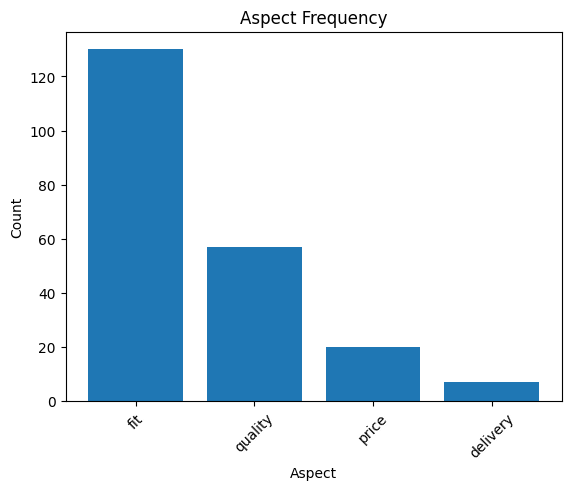

In [ ]:
import matplotlib.pyplot as plt

aspect_counts = {}

for row in df_test["aspect_sentiments"]:
    for aspect in row.keys():
        aspect_counts[aspect] = aspect_counts.get(aspect, 0) + 1

plt.bar(aspect_counts.keys(), aspect_counts.values())
plt.title("Aspect Frequency")
plt.xlabel("Aspect")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

⚠️ One limitation

Keyword-based aspect extraction

→ may miss implicit aspects

→ cannot detect sarcasm/context

That’s fine — just mention it.

In [ ]:
import json
from google.colab import files

# 1. Save the current notebook state first (Press Ctrl+S)
# 2. This code reads the notebook file, removes the broken 'widgets' metadata,
#    but keeps all your graphs and results.

input_file = '/content/drive/MyDrive/sentiment-analysis-project/notebooks/03_Deep_Learning_Setup.ipynb' # Update this path!
output_file = 'Cleaned_Section_3.ipynb'

with open(input_file, 'r', encoding='utf-8') as f:
    nb_data = json.load(f)

# Remove the problematic widgets metadata that causes the 'state' error
if 'widgets' in nb_data.get('metadata', {}):
    del nb_data['metadata']['widgets']
    print("Fixed the 'state' key issue!")

# Save the cleaned version
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(nb_data, f, indent=2)

# Force a download to your ASUS Vivobook
files.download(output_file)

Fixed the 'state' key issue!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# For PyTorch
import torch
torch.save(model.state_state_dict(), '/content/drive/MyDrive/sentiment-analysis-project/models)

# For TensorFlow/Keras
model.save('/content/drive/MyDrive/ML_Project/models/final_model.h5')

SyntaxError: unterminated string literal (detected at line 3) (2000834712.py, line 3)

In [1]:
import os
import pickle
import pandas as pd
from google.colab import drive, files
from sklearn.metrics import accuracy_score

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Project Directory
PROJECT_ROOT = '/content/drive/MyDrive/sentiment-analysis-project'
os.chdir(PROJECT_ROOT)

# Create folders
folders = ["models", "artifacts", "results"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("--- Starting Export ---")

# 3. Save the Model (LSTM)
# Using accuracy (which exists) instead of acc
model_path = "models/lstm_model.h5"
model.save(model_path)
print(f"✅ Model saved to: {model_path}")

# 4. Save Preprocessing Artifacts
with open("artifacts/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("artifacts/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✅ Tokenizer and Label Encoder saved to artifacts/")

# 5. Save Results
df_test.to_csv("results/aspect_results.csv", index=False)

# Use 'accuracy' instead of 'acc'
results_df = pd.DataFrame({
    "Model": ["LSTM", "BERT"],
    "Accuracy": [accuracy, accuracy_score(y_true, y_pred)]
})
results_df.to_csv("results/model_comparison.csv", index=False)
print("✅ CSV results saved to results/")

print("\n--- Triggering Local Downloads ---")

files_to_download = [
    model_path,
    "artifacts/tokenizer.pkl",
    "artifacts/label_encoder.pkl",
    "results/aspect_results.csv",
    "results/model_comparison.csv"
]

for file_path in files_to_download:
    if os.path.exists(file_path):
        files.download(file_path)

print("All tasks complete!")

Mounted at /content/drive
--- Starting Export ---


NameError: name 'model' is not defined